In [1]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import torch as t
import seaborn as sns

In [2]:
graph_type = 'simple'

def load_file_get_metrics(f_path):
    with open(f_path, 'r') as f:
        scores = json.load(f)
        gen_diff_mean, gen_diff_std = scores['gen_diff']['overall']['mean'], scores['gen_diff']['overall']['std']
    scores = {
        'gen_diff': (gen_diff_mean, gen_diff_std)
    }
    return scores

def format_label(metric, steer_type, harm_type):
    metric_label = 'dirKL' if metric.startswith('dkl') else metric
    steer_label = 'steered' if steer_type == 'steer' else steer_type
    return f"{metric_label} | {steer_label} | {harm_type}"

def get_all_scores(model_path, n, learn_type, metric_types, steer_types, harm_types):
    dir_path = f"circuits/{model_path.split('/')[-1]}"
    all_scores = defaultdict(list)
    for metric in metric_types:
        for steer_type in steer_types:
            for harm_type in harm_types:
                exp_name = f"{learn_type}{metric}_{steer_type}_{harm_type}"
                label = format_label(metric, steer_type, harm_type)

                f_faith = f"faithfulness_{n}_{graph_type}_harmless.json"
                f_path = os.path.join(dir_path, exp_name, f_faith)
                if os.path.exists(f_path):
                    scores_harmless = load_file_get_metrics(f_path)
                    all_scores['gen_diff_harmless'].append((exp_name, scores_harmless['gen_diff'][0], scores_harmless['gen_diff'][1], label))
                else:
                    print(f'{f_path} does not exist')

                f_faith = f"faithfulness_{n}_{graph_type}_harmful.json"
                f_path = os.path.join(dir_path, exp_name, f_faith)
                if os.path.exists(f_path):
                    scores_harmful = load_file_get_metrics(f_path)
                    all_scores['gen_diff_harmful'].append((exp_name, scores_harmful['gen_diff'][0], scores_harmful['gen_diff'][1], label))
                else:
                    print(f'{f_path} does not exist')
    return all_scores

def get_scores(f):
    if os.path.exists(f):
        scores = load_file_get_metrics(f)
    
    return scores['gen_diff'][0], scores['gen_diff'][1]

In [3]:
def get_n_scores(model_path, ns, exp_name, method='simple', invert=False):
    dir_path = f"../circuits/{model_path.split('/')[-1]}"
    harmless_scores = []
    harmful_scores = []

    for n in ns:
        f_faith = f"faithfulness_{n}_{method}_harmless{'_invert' if invert else ''}.json"
        f_path = os.path.join(dir_path, exp_name, f_faith)
        if os.path.exists(f_path):
            scores_harmless = load_file_get_metrics(f_path)
            harmless_scores.append((scores_harmless['gen_diff'][0], scores_harmless['gen_diff'][1]))
        else:
            print(f'{f_path} does not exist')

        f_faith = f"faithfulness_{n}_{method}_harmful{'_invert' if invert else ''}.json"
        f_path = os.path.join(dir_path, exp_name, f_faith)
        if os.path.exists(f_path):
            scores_harmful = load_file_get_metrics(f_path)
            harmful_scores.append((scores_harmful['gen_diff'][0], scores_harmful['gen_diff'][1]))
        else:
            print(f'{f_path} does not exist')
    return harmful_scores, harmless_scores

In [4]:
def line_plot(data: list[tuple], labels: list, title: str, xs: list, threshold: float = None, colors=None, xticks=None, legend_loc=None, num_edges=2212):
    import seaborn as sns

    palette = sns.color_palette("muted", len(data))

    fig, ax = plt.subplots(figsize=(8, 4))
    
    if colors is None:
        colors = [None] * len(data)
    
    if xticks is None:
        xticks = xs

    for scores, label, p_color, color in zip(data, labels, palette, colors):
        if color is None: color = p_color
        means = np.array([s[0] for s in scores])
        stds = np.array([s[1] for s in scores])
        x = xs[:len(means)]
        ax.plot(x, means, marker=None, label=label, color=color, linewidth=2)
        # ax.fill_between(x, means - stds, means + stds, alpha=0.2, color=color)

    if threshold is not None:
        ax.axhline(y=threshold, color='gray', linestyle='--', linewidth=1.2)

    ax.tick_params(axis='both', labelsize=13)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    ax.set_xlabel(f'# Edges (/{num_edges})', fontsize=15)
    ax.set_ylabel('Faithfulness', fontsize=15)
    ax.legend(loc=(legend_loc if legend_loc else 'right'), fontsize=13)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
    sns.reset_defaults()

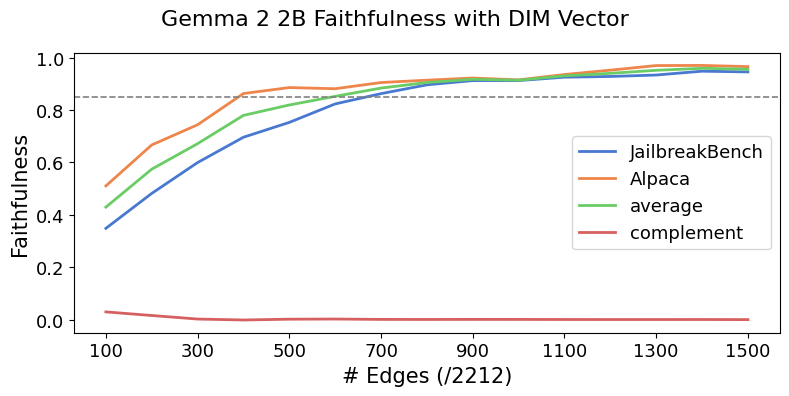

In [113]:
# paper ready graph: harmless and harmful g2
ns = [100,200,300,400,500,600,700,800,900,1000, 1100, 1200, 1300, 1400, 1500]
g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit'
)
invert_g2_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit',
    invert=True
)
xticks=[100, 300, 500, 700, 900, 1100, 1300, 1500]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)], 
    ['JailbreakBench', 'Alpaca', 'average', 'complement'],
    "Gemma 2 2B Faithfulness with DIM Vector",
    # "",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)

([(0.3845754029034114, 0.05140494976708358), (0.5748083524192709, 0.07509532487166329), (0.6806070601265045, 0.06864338413637217), (0.7837619385740221, 0.07623607181872813), (0.8526910436810178, 0.07006858322909634), (0.8925128063006531, 0.0557836150766125), (0.8954233391605592, 0.05073967232087157), (0.9264461986316547, 0.05334670811408009), (0.9534363550983351, 0.047307780955097675), (0.9507682614883369, 0.043725421845722576), (0.9674717528882425, 0.03900490004129403), (0.9769617192688443, 0.03540992377943412), (0.9840064351665113, 0.03433081584932794), (0.987007008266487, 0.028754748396227908), (0.9936560014827847, 0.025494939182269607)], [(0.3750224783117012, 0.09592806514955082), (0.5468050309871102, 0.10883161531565312), (0.6321537086645347, 0.10197025619885902), (0.6927974350917312, 0.10277919290612499), (0.723049416710876, 0.10171575726649254), (0.7536027810482938, 0.10303843405072981), (0.8010754345601595, 0.09639550952973176), (0.8231108000854145, 0.09206679762509415), (0.846

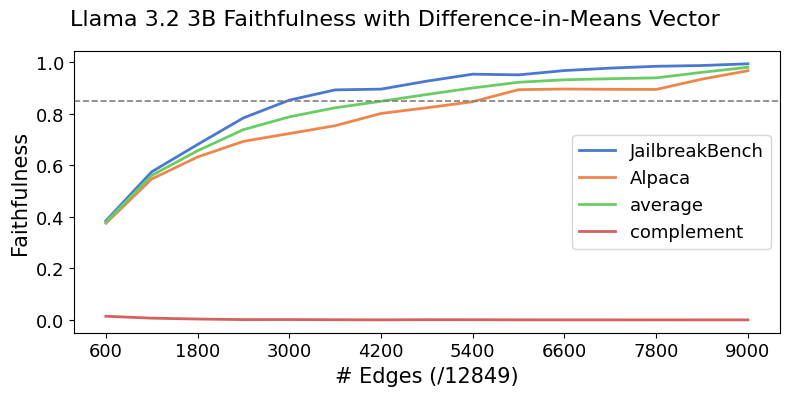

In [107]:
# paper ready graph: harmless and harmful l3
ns = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]
l3_dim_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns,
    'dim_logit'
)
invert_l3_dim_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns,
    'dim_logit',
    invert=True
)
print(l3_dim_logit)
xticks=[600,1800,3000,4200,5400,6600,7800,9000]
avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)], 
    ['JailbreakBench', 'Alpaca', 'average', 'complement'],
    # "",
    "Llama 3.2 3B Faithfulness with Difference-in-Means Vector",
    ns,
    0.85,
    colors=[None, None, None, None],
    num_edges=12849,
    xticks=xticks
)

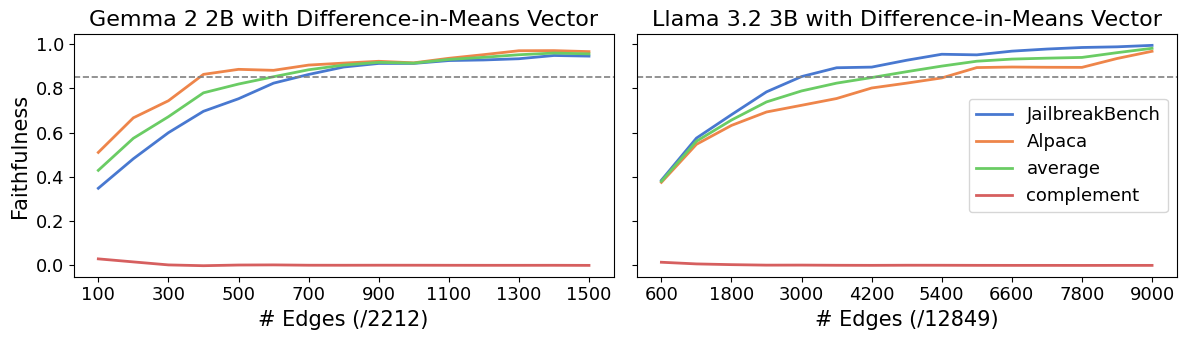

In [140]:
fig, axs = plt.subplots(1,2,figsize=(12,3.5), sharey=True)

palette = sns.color_palette("muted", 4)

g2_xticks = [100, 300, 500, 700, 900, 1100, 1300, 1500]
g2_xs = [100,200,300,400,500,600,700,800,900,1000, 1100, 1200, 1300, 1400, 1500]
l3_xticks = [600,1800,3000,4200,5400,6600,7800,9000]
l3_xs = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,6600,7200,7800,8400,9000]

g2_data = [g2_dim_logit[0], g2_dim_logit[1], avg(g2_dim_logit), avg(invert_g2_dim_logit)]
labels = ['JailbreakBench', 'Alpaca', 'average', 'complement']
for scores, label, p_color in zip(g2_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[0].plot(g2_xs, means, marker=None, label=label, color=p_color, linewidth=2)

axs[0].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[0].tick_params(axis='both', labelsize=13)
axs[0].set_xticks(g2_xticks)
axs[0].set_xticklabels(g2_xticks)
axs[0].set_xlabel(f'# Edges (/2212)', fontsize=15)
axs[0].set_ylabel('Faithfulness', fontsize=15)
axs[0].set_title("Gemma 2 2B with Difference-in-Means Vector", fontsize=16)

l3_data = [l3_dim_logit[0], l3_dim_logit[1], avg(l3_dim_logit), avg(invert_l3_dim_logit)]
for scores, label, p_color in zip(l3_data, labels, palette):
    means = np.array([s[0] for s in scores])
    stds = np.array([s[1] for s in scores])
    axs[1].plot(l3_xs, means, marker=None, label=label, color=p_color, linewidth=2)
axs[1].axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
axs[1].set_xticks(l3_xticks)
axs[1].set_xticklabels(l3_xticks, fontsize=13)
axs[1].set_xlabel(f'# Edges (/12849)', fontsize=15)
axs[1].set_title("Llama 3.2 3B with Difference-in-Means Vector", fontsize=16)


axs[1].legend(loc='right', fontsize=13)
plt.tight_layout()
plt.show()
sns.reset_defaults()



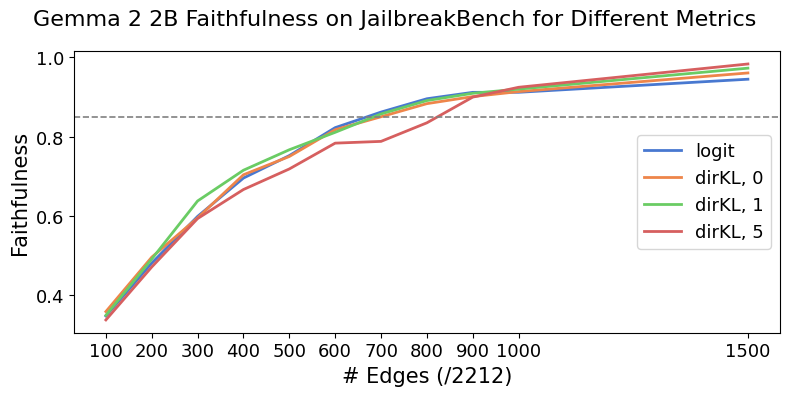

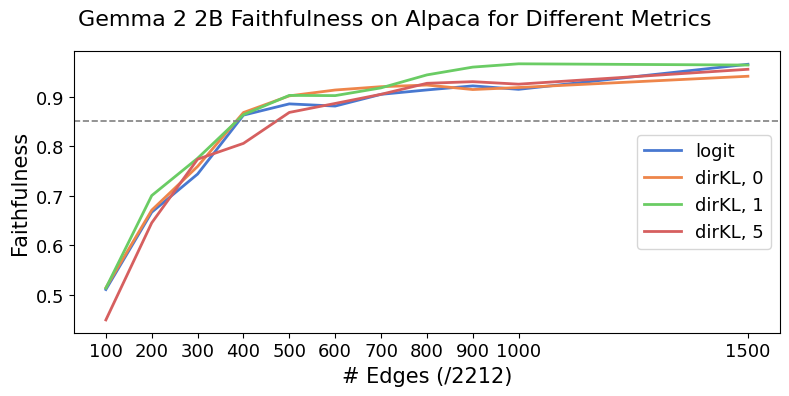

In [5]:
# based on metric
ns = [100,200,300,400,500,600,700,800,900,1000,1500]
dim_logit_harm, dim_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_logit"
)
dim_dkl0_harm, dim_dkl0_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl0"
)
dim_dkl1_harm, dim_dkl1_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl1"
)
dim_dkl5_harm, dim_dkl5_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl5"
)

threshold = 0.85
line_plot(
    [dim_logit_harm, dim_dkl0_harm, dim_dkl1_harm, dim_dkl5_harm], 
    ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5'],
    "Gemma 2 2B Faithfulness on JailbreakBench for Different Metrics",
    ns,
    threshold
)
line_plot(
    [dim_logit_safe, dim_dkl0_safe, dim_dkl1_safe, dim_dkl5_safe], 
    ['logit', 'dirKL, 0', 'dirKL, 1', 'dirKL, 5'],
    "Gemma 2 2B Faithfulness on Alpaca for Different Metrics",
    ns,
    threshold
)


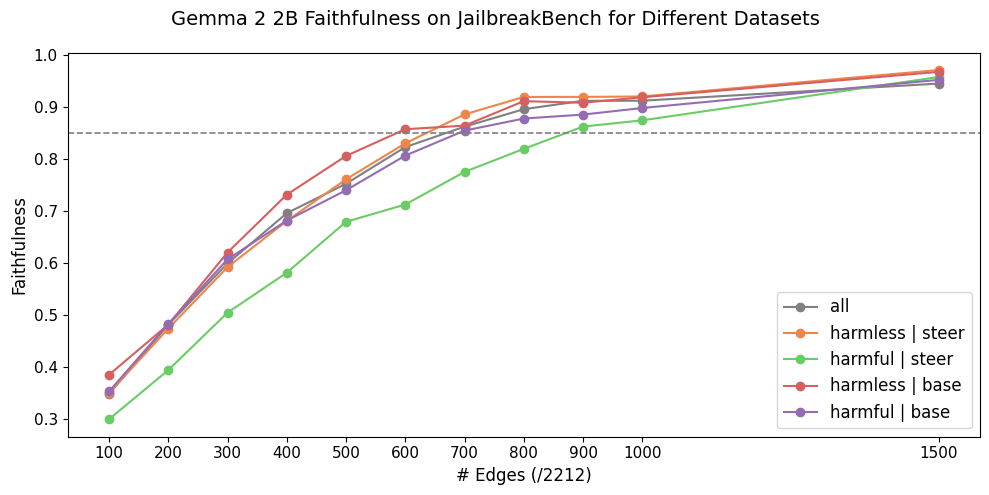

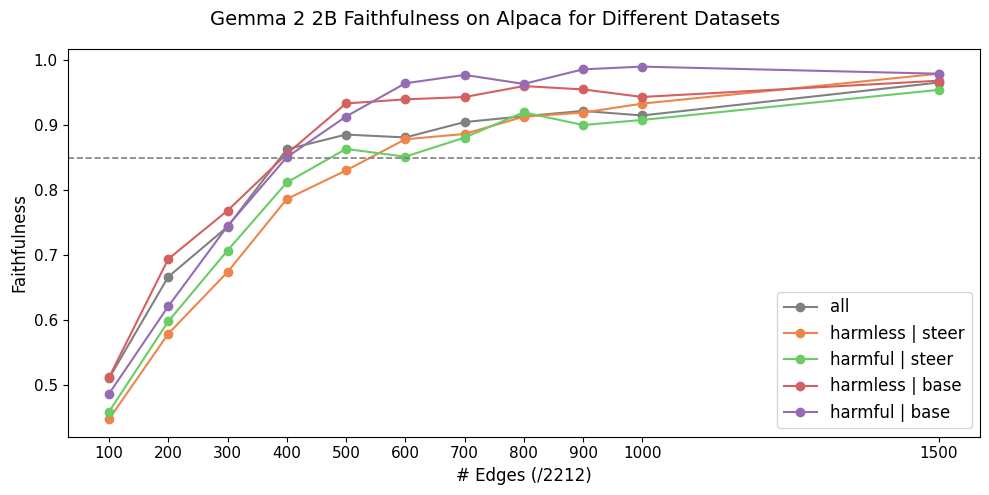

In [ ]:
# vary datasets

ns = [100,200,300,400,500,600,700,800,900,1000,1500]
base_harmless = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_base_harmless"
)
base_harmful = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_base_harmful"
)
steer_harmless = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_steer_harmful"
)
steer_harmful = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "logit_steer_harmless"
)
all = get_n_scores(
    'google/gemma-2-2b-it',
    ns=ns,
    exp_name = 'dim_logit'
)

threshold = 0.85

line_plot(
    [all[0], steer_harmless[0], steer_harmful[0], base_harmless[0], base_harmful[0]], 
    ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
    "Gemma 2 2B Faithfulness on JailbreakBench for Different Circuit Datasets",
    ns,
    threshold,
    colors=['gray', None, None, None, None]
)
line_plot(
    [all[1], steer_harmless[1], steer_harmful[1], base_harmless[1], base_harmful[1]], 
    ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
    "Gemma 2 2B Faithfulness on Alpaca for Different Circuit Datasets",
    ns,
    threshold,
    colors=['gray', None, None, None, None]
)


tensor(0.7759) tensor(0.7829)


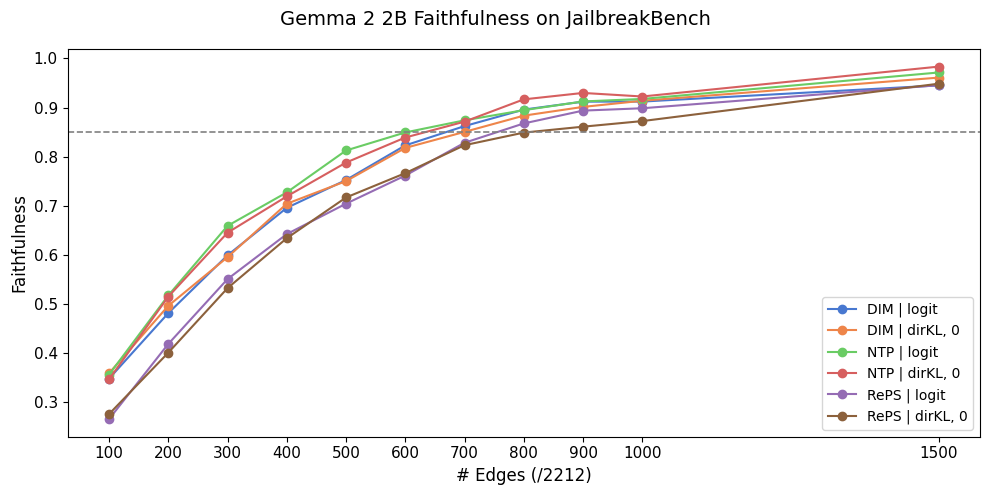

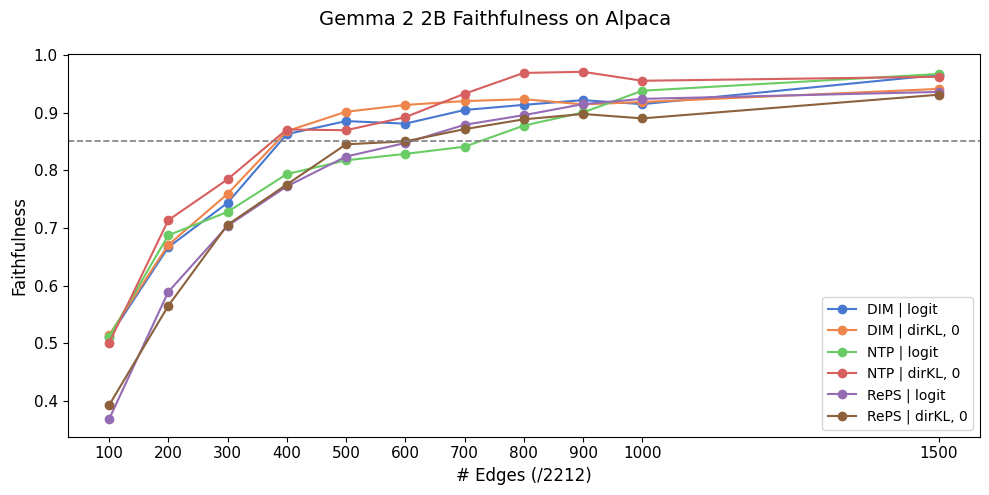

In [31]:
# vary steer

ns = [100,200,300,400,500,600,700,800,900,1000,1500]
dim_logit_harm, dim_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_logit"
)
dim_dirKL_harm, dim_dirKL_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "dim_dkl0"
)
ntp_logit_harm, ntp_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "ntp_logit"
)
ntp_dirKL_harm, ntp_dirKL_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "ntp_dkl0"
)
reps_logit_harm, reps_logit_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "reps_logit"
)
reps_dirKL_harm, reps_dirKL_safe = get_n_scores(
    'google/gemma-2-2b-it',
    ns = ns,
    exp_name = "reps_dkl0"
)

def foo(scores):
    return [s[0] for s in scores]
logit_scores = t.tensor(
    foo(dim_logit_safe)+ foo(dim_logit_harm)+
    foo(ntp_logit_safe)+ foo(ntp_logit_harm)+
    foo(reps_logit_safe)+ foo(reps_logit_harm)
)
dirKL_scores = t.tensor(
    foo(dim_dirKL_safe)+ foo(dim_dirKL_harm)+
    foo(ntp_dirKL_safe)+ foo(ntp_dirKL_harm)+
    foo(reps_dirKL_safe)+ foo(reps_dirKL_harm)
)
print(logit_scores.mean(), dirKL_scores.mean())

threshold = 0.85

line_plot(
    [dim_logit_harm, dim_dirKL_harm, ntp_logit_harm, ntp_dirKL_harm, reps_logit_harm, reps_dirKL_harm], 
    ['DIM | logit', 'DIM | dirKL, 0', 'NTP | logit', 'NTP | dirKL, 0', 'RePS | logit', 'RePS | dirKL, 0'],
    "Gemma 2 2B Faithfulness on JailbreakBench",
    ns,
    threshold
)
line_plot(
    [dim_logit_safe, dim_dirKL_safe, ntp_logit_safe, ntp_dirKL_safe, reps_logit_safe, reps_dirKL_safe], 
    ['DIM | logit', 'DIM | dirKL, 0', 'NTP | logit', 'NTP | dirKL, 0', 'RePS | logit', 'RePS | dirKL, 0'],
    "Gemma 2 2B Faithfulness on Alpaca",
    ns,
    threshold
)


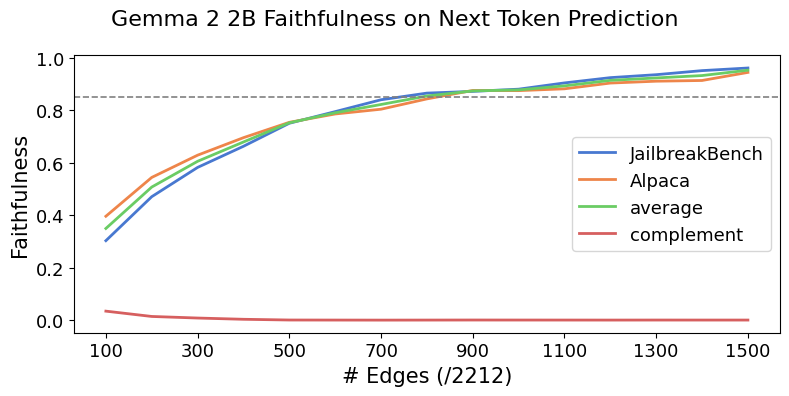

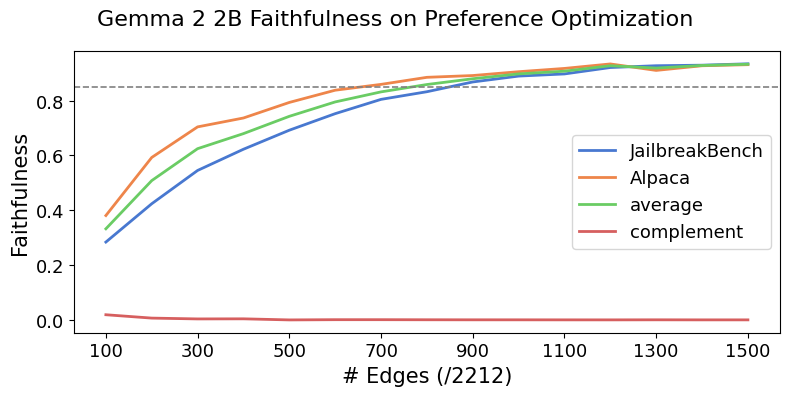

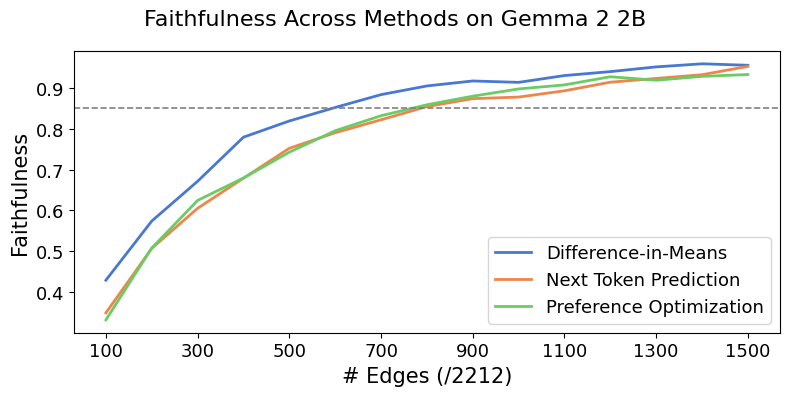

In [8]:
# paper ready graph: harmful and harmless g2 ntp
# ns = [100,200,300,400,500,600,700,800,900,1000,1500]
ns = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]

ntp_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'ntp_logit'
)
reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'reps_logit'
)
dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit'
)
invert_ntp_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'ntp_logit',
    invert=True
)
invert_reps_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'reps_logit',
    invert=True
)
invert_dim_logit = get_n_scores(
    'google/gemma-2-2b-it',
    ns,
    'dim_logit',
    invert=True
)
xticks =[100,300,500,700,900,1100,1300,1500]

avg = lambda x: [((a[0]+b[0])/2,-1) for a, b in zip(x[0],x[1])]

line_plot(
    [ntp_logit[0], ntp_logit[1], avg(ntp_logit), avg(invert_ntp_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Next Token Prediction",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)
line_plot(
    [reps_logit[0], reps_logit[1], avg(reps_logit), avg(invert_reps_logit)], 
    ['JailbreakBench', 'Alpaca', "average", 'complement'],
    "Gemma 2 2B Faithfulness on Preference Optimization",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks
)
line_plot(
    [avg(dim_logit), avg(ntp_logit), avg(reps_logit)], 
    ['Difference-in-Means', 'Next Token Prediction', "Preference Optimization"],
    "Faithfulness Across Methods on Gemma 2 2B",
    ns,
    0.85,
    colors=[None, None, None, None],
    xticks=xticks,
    legend_loc='lower right'
)


In [10]:
dim_ns = [700]
ntp_ns = [800]
reps_ns = [800]
model_path = 'google/gemma-2-2b-it'
dim_on_ntp_scores = get_n_scores(model_path, dim_ns,
    'ntp_logit/dim_on_ntp'
)
dim_on_reps_scores = get_n_scores(model_path,
    dim_ns,
    'reps_logit/dim'
)
dim_on_dim_scores = get_n_scores(model_path,
    dim_ns,
    'dim_logit'
)
dim_on_rand_scores = get_n_scores(model_path,
    dim_ns,
    'dim_logit',
    method='random'
)
ntp_on_ntp_scores = get_n_scores(model_path, ntp_ns,
    'ntp_logit'
)
ntp_on_reps_scores = get_n_scores(model_path,
    ntp_ns,
    'reps_logit/ntp_on_reps'
)
ntp_on_dim_scores = get_n_scores(model_path,
    ntp_ns,
    'dim_logit/ntp_on_dim'
)
ntp_on_rand_scores = get_n_scores(model_path,
    ntp_ns,
    'ntp_logit',
    method='random'
)
reps_on_ntp_scores = get_n_scores(model_path, reps_ns,
    'ntp_logit/reps_on_ntp'
)
reps_on_reps_scores = get_n_scores(model_path,
    reps_ns,
    'reps_logit'
)
reps_on_dim_scores = get_n_scores(model_path,
    reps_ns,
    'dim_logit/reps_on_dim'
)
reps_on_rand_scores = get_n_scores(model_path,
    reps_ns,
    'reps_logit',
    method='random'
)

def avg(scores):
    harmful, harmless = scores
    return (harmful[0][0] + harmless[0][0]) / 2


vector_labels = ['DIM', 'NTP', 'PO']
circuit_labels = ['DIM', 'NTP', 'PO', 'random']


{'DIM': [0.8834083909922033, 0.8574409368721142, 0.8536423569707225, 0.12835541515153231], 'NTP': [0.8255328178991664, 0.8541710733068173, 0.8160371543745442, 0.1463672460028112], 'PO': [0.8879876221250621, 0.8450508564777717, 0.8585878969034866, 0.19476202869929937]}


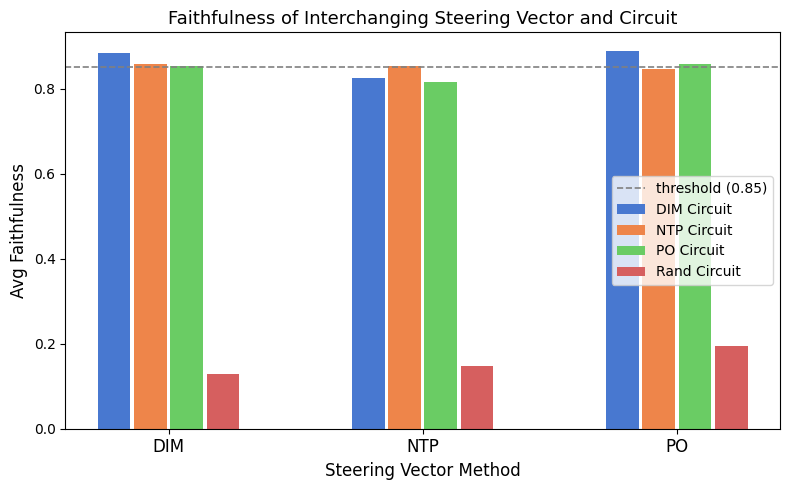

In [12]:
data = {
    'DIM':  [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),
    avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP':  [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),
    avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':   [avg(reps_on_dim_scores), avg(reps_on_ntp_scores),
   avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
print(data)

circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Rand Circuit']
steer_methods  = list(data.keys())
n_groups  = len(steer_methods)
n_bars    = len(circuit_labels)

x = np.arange(n_groups)*0.7
bar_width = 0.10
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width

palette = sns.color_palette("muted", n_bars)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, color) in enumerate(zip(circuit_labels, palette)):
    heights = [data[m][i] for m in steer_methods]
    ax.bar(x + offsets[i], heights, width=bar_width*0.9, label=label, color=color)

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2, label='threshold (0.85)')
ax.set_xticks(x)
ax.set_xticklabels(steer_methods, fontsize=12)
ax.set_ylabel('Avg Faithfulness', fontsize=12)
ax.set_xlabel('Steering Vector Method', fontsize=12)
ax.set_title('Faithfulness of Interchanging Steering Vector and Circuit', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1313550/3017846381.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)


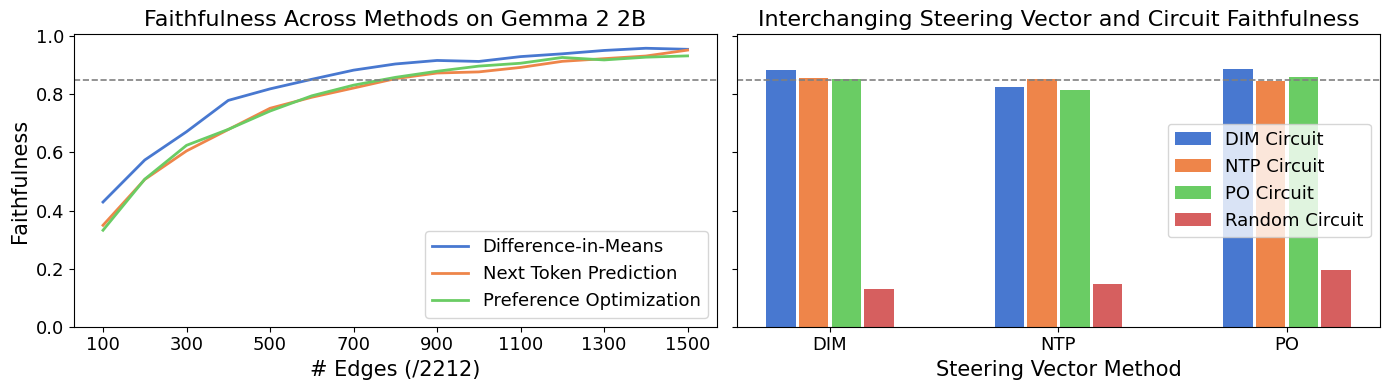

In [18]:
# Combined figure: "Faithfulness Across Methods" (line) + "Interchanging Steering Vector and Circuit" (bar)
ns_line = [100,200,300,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500]
avg_list = lambda x: [((a[0]+b[0])/2, -1) for a, b in zip(x[0], x[1])]

line_data   = [avg_list(dim_logit), avg_list(ntp_logit), avg_list(reps_logit)]
line_labels = ['Difference-in-Means', 'Next Token Prediction', 'Preference Optimization']

bar_data = {
    'DIM': [avg(dim_on_dim_scores),  avg(dim_on_ntp_scores),  avg(dim_on_reps_scores),  avg(dim_on_rand_scores)],
    'NTP': [avg(ntp_on_dim_scores),  avg(ntp_on_ntp_scores),  avg(ntp_on_reps_scores),  avg(ntp_on_rand_scores)],
    'PO':  [avg(reps_on_dim_scores), avg(reps_on_ntp_scores), avg(reps_on_reps_scores), avg(reps_on_rand_scores)],
}
bar_circuit_labels = ['DIM Circuit', 'NTP Circuit', 'PO Circuit', 'Random Circuit']
steer_methods = list(bar_data.keys())

palette = sns.color_palette("muted", 4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# --- Left: line plot ---
for scores, label, color in zip(line_data, line_labels, palette[:3]):
    means = np.array([s[0] for s in scores])
    ax1.plot(ns_line, means, marker=None, label=label, linewidth=2, color=color)
ax1.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax1.set_xticks([100,300,500,700,900,1100,1300,1500])
ax1.set_xticklabels([100,300,500,700,900,1100,1300,1500], fontsize=13)
ax1.set_xlabel('# Edges (/2212)', fontsize=15)
ax1.set_ylabel('Faithfulness', fontsize=15)
ax1.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=13)
ax1.set_title('Faithfulness Across Methods on Gemma 2 2B', fontsize=16)
ax1.legend(fontsize=13, loc='lower right')

# --- Right: grouped bar plot ---
x = np.arange(len(steer_methods)) * 0.7
bar_width = 0.10
offsets = np.linspace(-(len(bar_circuit_labels)-1)/2, (len(bar_circuit_labels)-1)/2, len(bar_circuit_labels)) * bar_width

for i, (label, color) in enumerate(zip(bar_circuit_labels, palette)):
    heights = [bar_data[m][i] for m in steer_methods]
    ax2.bar(x + offsets[i], heights, width=bar_width * 0.9, label=label, color=color)

ax2.axhline(y=0.85, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xticks(x)
ax2.set_xticklabels(steer_methods, fontsize=13)
ax2.set_xlabel('Steering Vector Method', fontsize=15)
ax2.set_title('Interchanging Steering Vector and Circuit Faithfulness', fontsize=16)
ax2.legend(fontsize=13, loc='right')

plt.tight_layout()
plt.savefig("faith_methods_combined.pdf", bbox_inches='tight')
plt.show()


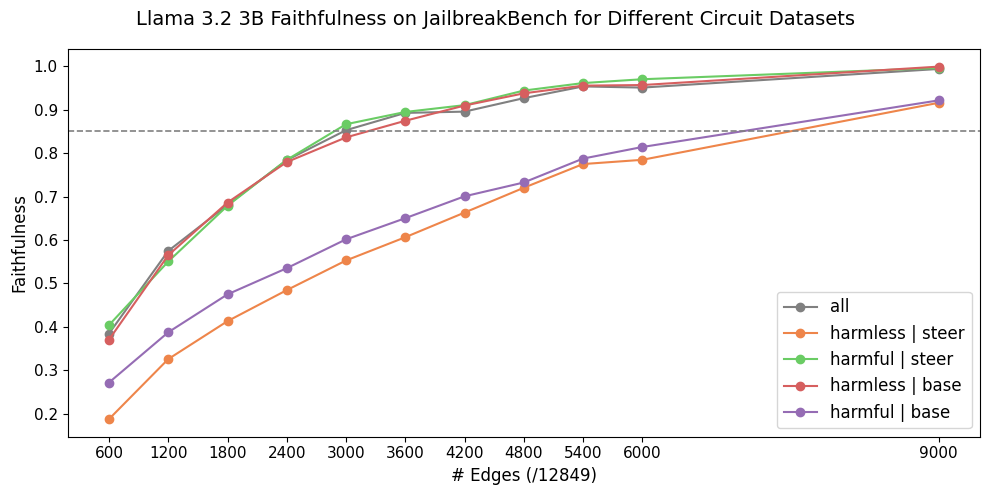

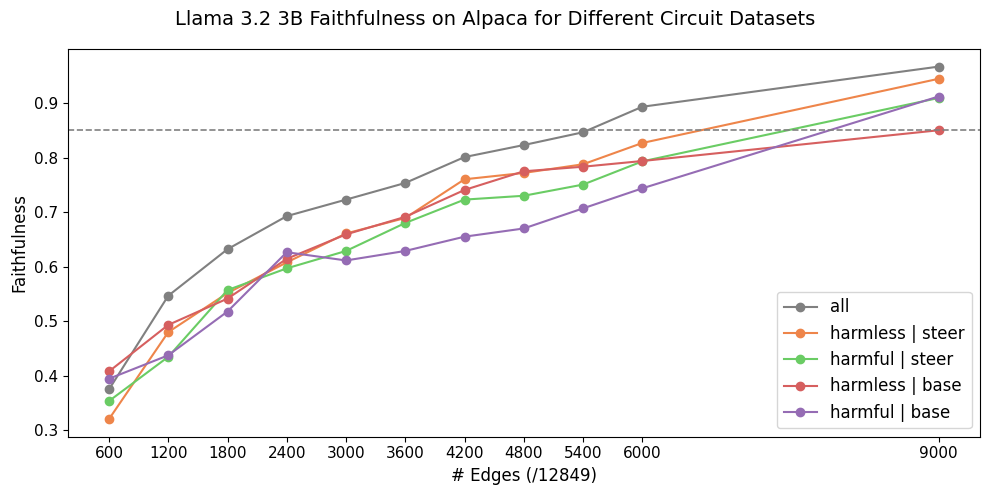

In [36]:
# paper ready graph
ns = [600,1200,1800,2400,3000,3600,4200,4800,5400,6000,9000]
all_logit = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "dim_logit"
)
logit_steer_harmless = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_steer_harmless"
)
logit_steer_harmful = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_steer_harmful"
)
logit_base_harmless = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_base_harmless"
)
logit_base_harmful = get_n_scores(
    'meta-llama/Llama-3.2-3B-Instruct',
    ns = ns,
    exp_name = "logit_base_harmful"
)


line_plot(
    [all_logit[0], logit_steer_harmless[0], logit_steer_harmful[0], logit_base_harmless[0], logit_base_harmful[0]], 
    ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
    "Llama 3.2 3B Faithfulness on JailbreakBench for Different Circuit Datasets",
    ns,
    0.85,
    num_edges=12849,
    colors=['gray', None, None, None, None]
)
line_plot(
    [all_logit[1], logit_steer_harmless[1], logit_steer_harmful[1], logit_base_harmless[1], logit_base_harmful[1]], 
    ['all', 'harmless | steer', 'harmful | steer', 'harmless | base', 'harmful | base'],
    "Llama 3.2 3B Faithfulness on Alpaca for Different Circuit Datasets",
    ns,
    0.85,
    num_edges=12849,
    colors=['gray', None, None, None, None]
)
